# Inverse UQ example: Shocktube

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import umbridge as um

from scipy.integrate import solve_ivp

import tinyDA as tda

In [115]:
np.random.seed(42)

We implement two slightly incompatible models. `UmbridgeArepoModel` obeys the UM-Bridge interface, and `NpArepoModel` is a wrapper that is compatible with tinyDA.

In [118]:
class UmbridgeArepoModel(um.Model):
    def __init__(self):
        super().__init__("forward")

    def get_input_sizes(self, config):
        return [2]
    
    def get_output_sizes(self, config):
        # nT = 10
        return [10]
    
    def __call__(self, parameters, config={}):
        return [[parameters[0], parameters[1], 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]

    def supports_evaluate(self):
        return True
    
class NpArepoModel(um.Model):
    def __init__(self):
        self.inner = UmbridgeArepoModel()

    def __call__(self, parameters):
        return np.array(self.inner(parameters)[0]), True

### Set up the true model

In [94]:
# set the true parameters. Our (noisy) measurements are based on these.
p_L = 1.0 # initial pressure of the left half
p_R = 0.1 # initial pressure of the right half

# collect the parameters in a vector. 
# we sample the log of the parameters and take the exponential
# inside the model to keep the parameters positive.
true_parameters = np.array([p_L, p_R])

# initalise the true model and solve it
my_model = NpArepoModel()
y_true = my_model(true_parameters)[0]
print(y_true)

[1.  0.1 0.  0.  0.  0.  0.  0.  0.  0. ]


### Set up the forward models

In [95]:
# n_data = 25 # number of datapoints
# t_eval_data = np.linspace(t_span[0], t_span[1], n_data) # datapoints

# # fine model
# my_fine_model = PredatorPreyModel(t_eval_data, method='Radau') # initialise model

# # coarse model
# my_coarse_model = PredatorPreyModel(t_eval_data, method='RK45') # initialise model

### Generate data

In [116]:
# set the noise level
sigma = 0.1

target = np.array([1.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

experimental_measurements = np.array([
    [1.        , 1.        , 1.        , 0.1       , 0.1       , 0.1       ],
    [1.        , 1.        , 0.49247185, 0.44178273, 0.1       ,
    0.1       ],
    [1.        , 0.64355649, 0.44178273, 0.44178273, 0.44178273,
    0.1       ],
    [0.70202924, 0.49247185, 0.44178273, 0.44178273, 0.44178273,
    0.44178273],
    [0.56368859, 0.44178273, 0.44178273, 0.44178273, 0.44178273,
    0.44178273],
    [0.49247185, 0.44178273, 0.44178273, 0.44178273, 0.44178273,
    0.44178273]])

flattened_measurements = experimental_measurements.flatten()
print(flattened_measurements)

noise = np.random.normal(scale=sigma, size=(10)) # fine noise
data = target + noise # noisy fine data.
data[data < 0] = 0 # make sure all the data is positive.

[1.         1.         1.         0.1        0.1        0.1
 1.         1.         0.49247185 0.44178273 0.1        0.1
 1.         0.64355649 0.44178273 0.44178273 0.44178273 0.1
 0.70202924 0.49247185 0.44178273 0.44178273 0.44178273 0.44178273
 0.56368859 0.44178273 0.44178273 0.44178273 0.44178273 0.44178273
 0.49247185 0.44178273 0.44178273 0.44178273 0.44178273 0.44178273]


### Plot the true model and the data

In [97]:
# y_coarse = PredatorPreyModel(t_eval, method='RK45')(true_parameters)[0]
# fig, axes = plt.subplots(figsize=(16,5), nrows=1, ncols=2)

# axes[0].set_title('Prey', fontsize=12)
# axes[0].plot(t_eval, y_true[:n_eval], '--', color='cornflowerblue')
# axes[0].plot(t_eval, y_coarse[:n_eval], '--', color='limegreen')
# axes[0].scatter(t_eval_data, data[:n_data], color='tomato')
# axes[0].tick_params(axis='both', labelsize=12)
# axes[0].set_xlabel('Time', fontsize=12)
# axes[0].set_ylim(0, 14); axes[0].set_ylabel('Density', fontsize=12)
# #axes[0].legend(loc=2, fontsize=12)

# axes[1].set_title('Predators', fontsize=12)
# axes[1].plot(t_eval, y_true[n_eval:], '--', color='cornflowerblue', label='Fine model')
# axes[1].plot(t_eval, y_coarse[n_eval:], '--', color='limegreen', label='Coarse model')
# axes[1].scatter(t_eval_data, data[n_data:], color='tomato', label='Noisy data')
# axes[1].tick_params(axis='both', labelsize=12)
# axes[1].set_xlabel('Time', fontsize=12)
# axes[1].set_ylim(0, 14); axes[1].set_ylabel('Density', fontsize=12)
# axes[1].legend(loc=1, fontsize=12)

# plt.show()

### Set up the statistical model  and draw some samples from the prior
We need a fairly well-informed prior, since the model is nonlinear and the data is quite noisy. Hence, we assume that we have pretty good knowledge about the birth- and death rates of the prey and predators, respectively. The predation rate and the growth rate for the predators are left to be fairly uncertain.

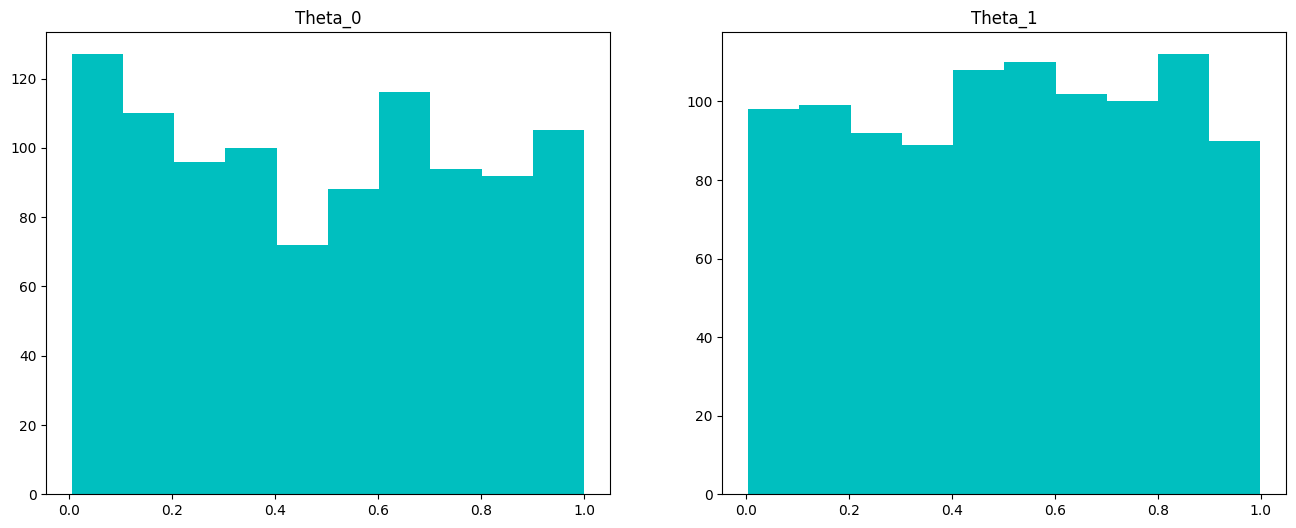

In [98]:
# prior distribution
# mean_prior = np.array([0.0, 0.0])
# cov_prior = np.diag([1.0, 1.0])
# my_prior = stats.multivariate_normal(mean_prior, cov_prior)
# low = [0, 0]
# high = [1, 1]
# my_prior = stats.uniform(loc=low, scale=high)
class MultivariatePrior:
    def __init__(self, low, high):
        self.low = np.array(low)
        self.high = np.array(high)
        self.dim = len(low)

    def logpdf(self, x):
        x = np.atleast_2d(x)
        in_range = np.all((x >= self.low) & (x <= self.high))
        return 0 if in_range else -np.inf  # np.where(in_range, 0, -np.inf)

    def rvs(self, size=1):
        if isinstance(size, int):
            size = (size, self.dim)
        elif isinstance(size, tuple) and len(size) == 1:
            size = size + (self.dim,)
        samples = np.random.uniform(self.low, self.high, size=size)
        if size == 1 or (isinstance(size, tuple) and size[0] == 1):
            return samples[0]
        return samples

# Set up the prior
low = np.array([0, 0])
high = np.array([1, 1])
my_prior = MultivariatePrior(low, high)

# draw some samples and plot them
prior_samples = my_prior.rvs(size=(1000, 2))
fig, axes = plt.subplots(nrows=1, ncols=2, figsize = (8*2, 6))
for i in range(2):
    axes[i].set_title('Theta_{}'.format(i))
    axes[i].hist(prior_samples[:,i], color='c')

In [99]:
# define the likelihood
cov_likelihood = sigma**2*np.eye(data.size)

my_loglike = tda.GaussianLogLike(data, cov_likelihood)

### Set up the link factories and get the MAP point

In [100]:
# set up the link factories
my_posterior = tda.Posterior(my_prior, my_loglike, my_model)

my_posteriors = [my_posterior]

my_posterior.prior.rvs()

array([0.53242068, 0.4110956 ])

In [101]:
# get the maximum a posteriori point.
MAP = tda.get_MAP(my_posterior)
MAP

/home/paul/temp/jupyter-kernels/dasci/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/home/paul/temp/jupyter-kernels/dasci/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/home/paul/temp/jupyter-kernels/dasci/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/home/paul/temp/jupyter-kernels/dasci/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/home/paul/temp/jupyter-kernels/dasci/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/home/paul/temp/jupyter-kernels/dasci/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encoun

array([0.99912006, 0.51434312])

### Set up the proposal

In [102]:
# random walk Metropolis
#rwmh_cov = np.eye(2)
#rmwh_scaling = 0.1
#rwmh_adaptive = True
#my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

# preconditioned Crank-Niconson
#pcn_scaling = 0.1
#pcn_adaptive = True
#my_proposal = tda.CrankNicolson(scaling=pcn_scaling, adaptive=pcn_adaptive)

# Adaptive Metropolis
am_cov = np.eye(true_parameters.size)
am_t0 = 100
am_sd = None
am_epsilon = 1e-6
am_adaptive = True
my_proposal = tda.AdaptiveMetropolis(C0=am_cov, t0=am_t0, sd=am_sd, epsilon=am_epsilon)

### Sample

In [110]:
import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 120
    burnin = 20

In [111]:
# initialise the chain
my_chain = tda.sample(my_posteriors, my_proposal, iterations=iterations, n_chains=2, initial_parameters=MAP, subchain_length=5, adaptive_error_model='state-independent', force_sequential=True)

Sampling chain 1/2
[0.99912006 0.51434312]


Running chain, α = 0.49: 100%|██████████| 12000/12000 [00:20<00:00, 583.18it/s]


Sampling chain 2/2
[0.99912006 0.51434312]


Running chain, α = 0.41: 100%|██████████| 12000/12000 [00:20<00:00, 595.95it/s]


### Diagnostics

In [112]:
print(my_chain['chain_0'][0].prior)
idata = tda.to_inference_data(my_chain, level='fine', burnin=burnin)

0


/home/paul/temp/jupyter-kernels/dasci/lib/python3.10/site-packages/arviz/data/inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


In [113]:
import arviz as az

In [114]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x0,0.938,0.050,0.846,1.000,0.001,0.001,1657.0,2079.0,1.0
x1,0.491,0.098,0.306,0.679,0.002,0.002,1541.0,2433.0,1.0


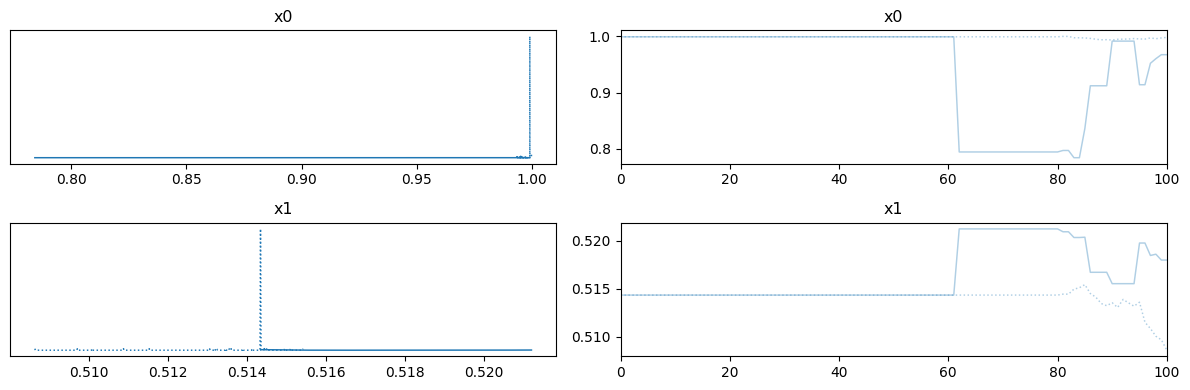

In [108]:
az.plot_trace(idata)
plt.tight_layout()
plt.show()

In [109]:
rv = stats.uniform(loc=np.array([0, 0]), scale=(np.array([1, 1])))
rv.rvs(size=(10, 2))

array([[0.03601882, 0.17522177],
       [0.86677035, 0.28247874],
       [0.95045917, 0.58162229],
       [0.43661419, 0.58008883],
       [0.51669839, 0.75877625],
       [0.28249607, 0.35305039],
       [0.8940943 , 0.94645651],
       [0.89255823, 0.41944799],
       [0.7803655 , 0.47633573],
       [0.49753985, 0.20468011]])